# BurstCube Data Types: CBD and TTE

BurstCube produces two primary time-series science data products for each of
its four detectors (`CS0`-`CS3`):

* **CBD** (continuous binned data): a pre-binned 16-channel time history of
  counts, nominally at 0.256 s resolution. Each observation day has an
  unfiltered (`_uf`) and a cleaned (`_cl`) version.
* **TTE** (time-tagged event data): an unbinned, 1024-channel photon list.
  Unlike GBM, BurstCube never had an onboard astrophysical trigger fire, so
  TTE exists only for 7 short commissioning/validation windows across the
  whole mission.

This notebook uses **2024-05-30** (`240530`) as the worked example, since it
is one of the 7 days with both CBD and TTE data, for detector `CS0`. It walks
through finding and downloading the data, `_uf` vs `_cl`, time selection,
rebinning, light curves, count spectra, and several of the caveats that
actually bite in practice.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gdt.core import data_path
from gdt.core.binning.binned import combine_by_factor
from gdt.core.binning.unbinned import bin_by_time
from gdt.core.plot.lightcurve import Lightcurve
from gdt.core.plot.spectrum import Spectrum

from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.missions.burstcube.tte import BurstCubeTTE
from gdt.missions.burstcube.hk import BurstCubeHK
from gdt.missions.burstcube.finders import BurstCubeObsFinder

OBS_ID = '240530'
DETECTOR = 'CS0'
%matplotlib inline

## Finding and downloading a day

Every BurstCube archive filename is fully determined by the observation day,
detector, and product type, so `BurstCubeObsFinder` does not need to list a
remote directory to know what to download -- it just downloads the exact
files. Not every day has data: day directories are **not contiguous**, and
only 7 days out of the whole mission have TTE.

In [2]:
download_dir = Path(data_path) / 'burstcube' / OBS_ID
download_dir.mkdir(parents=True, exist_ok=True)

finder = BurstCubeObsFinder()
finder.cd(OBS_ID)
print('Contents of the day directory:', finder.files)

cbd_cl_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='cl', verbose=False)
cbd_uf_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='uf', verbose=False)
tte_path, = finder.get_tte(download_dir, detectors=DETECTOR, verbose=False)
hk_path = finder.get_hk(download_dir, verbose=False)

print('CBD (cl):', cbd_cl_path)
print('CBD (uf):', cbd_uf_path)
print('TTE:', tte_path)
print('Detector HK:', hk_path)

Contents of the day directory: ['auxil', 'events', 'monitor']


CBD (cl): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_cl.fits.gz
CBD (uf): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_uf.fits.gz
TTE: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_tte_uf.evt.gz
Detector HK: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530csa.hk.gz


## Opening CBD: `_uf` vs `_cl`

`_uf` is the unfiltered data as telemetered; `_cl` has bad/unphysical
intervals (captured in the GTIs) removed. Both are read the same way, with
`BurstCubeCBD.open()`.

In [3]:
cbd_uf = BurstCubeCBD.open(cbd_uf_path)
cbd_cl = BurstCubeCBD.open(cbd_cl_path)

print(cbd_uf)
print()
print(cbd_cl)

<BurstCubeCBD: bc240530cs0_3cbd_uf.fits.gz;
 time range (np.float64(107629262.94600001), np.float64(107654399.922));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>

<BurstCubeCBD: bc240530cs0_3cbd_cl.fits.gz;
 time range (np.float64(107629263.202), np.float64(107634882.57));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>


In [4]:
print(f'_uf: {cbd_uf.data.size[0]} bins, {cbd_uf.gti.num_intervals} GTI segment(s)')
print(f'_cl: {cbd_cl.data.size[0]} bins, {cbd_cl.gti.num_intervals} GTI segment(s)')

_uf: 98188 bins, 4 GTI segment(s)
_cl: 12576 bins, 5 GTI segment(s)


## Caveat: `TIME_SYST_ERROR`

Every CBD (and TTE) row carries a per-row systematic timing uncertainty, a
consequence of BurstCube's GPS-based clock reconstruction (archive caveat
#11 has the full story: average drift per reboot 24 +/- 4.4 s, ground time
jams 38.4 +/- 2.4 s, down to 1.5 +/- 1.0 s once GPS sync was enabled). For
this particular day it happens to be a flat 1 s for every row -- do not
assume it is always constant; check it rather than ignore it.

In [5]:
print('TIME_SYST_ERROR (s): min={:.4f}  max={:.4f}  mean={:.4f}'.format(
    cbd_cl.time_syst_error.min(), cbd_cl.time_syst_error.max(),
    cbd_cl.time_syst_error.mean()))

TIME_SYST_ERROR (s): min=1.0000  max=1.0000  mean=1.0000


## Light curves

Integrating CBD over its full energy range with `to_lightcurve()` gives a
`TimeBins` object, which the `Lightcurve` plot class can render directly.

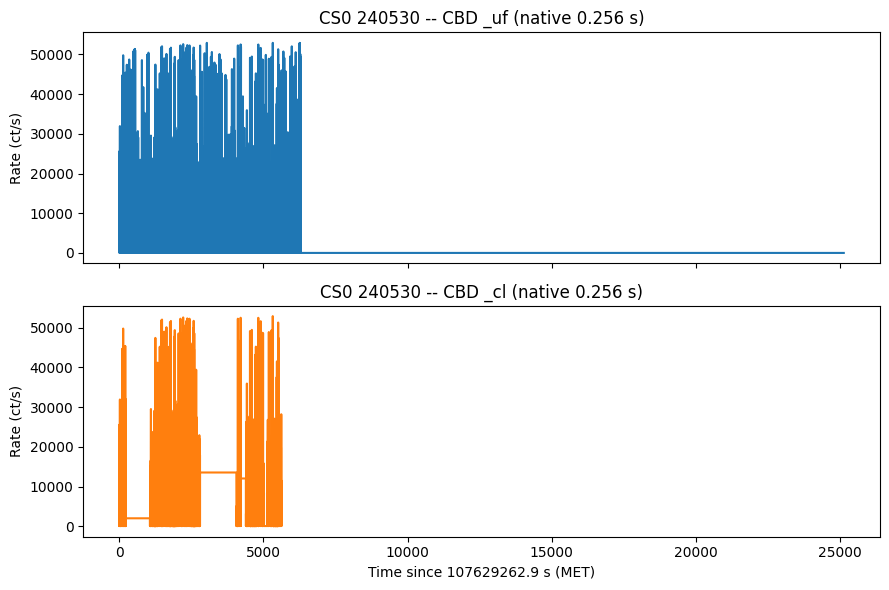

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

lc_uf = cbd_uf.to_lightcurve()
lc_cl = cbd_cl.to_lightcurve()

axes[0].step(lc_uf.lo_edges - cbd_uf.time_range[0], lc_uf.rates, where='post')
axes[0].set_title(f'{DETECTOR} {OBS_ID} -- CBD _uf (native 0.256 s)')
axes[0].set_ylabel('Rate (ct/s)')

axes[1].step(lc_cl.lo_edges - cbd_cl.time_range[0], lc_cl.rates, where='post', color='C1')
axes[1].set_title(f'{DETECTOR} {OBS_ID} -- CBD _cl (native 0.256 s)')
axes[1].set_xlabel(f'Time since {cbd_uf.time_range[0]:.1f} s (MET)')
axes[1].set_ylabel('Rate (ct/s)')

fig.tight_layout()
plt.show()

Even at native resolution, the `_cl` gaps are visible as blank stretches; the
`_uf` panel is denser but noisier and includes the intervals `_cl` removes.

## Rebinning

`Phaii.rebin_time` accepts any gdt-core binned-data rebinning function.
`combine_by_factor` merges a fixed number of consecutive bins and conserves
the total counts -- and, because gdt-core only rebins within a contiguous
run of bins, it never bridges a real gap.

**A caveat this surfaces in practice**: a handful of real bins arrive only
0.255 s after the previous one -- 1 ms short of the nominal 0.256 s
`TIMEDEL` (this is exactly what `BurstCubeCBD.blended` flags, per archive
caveat #9). The official caveat also states that CBD data blending is
*"filtered out in the archive clean files"*. What we measure here is
narrower than that: the `dt < TIMEDEL` test below flags 53 of this `_cl`
file's 12576 rows as arriving 1 ms short of the nominal cadence. Whether
that 1 ms shortfall is the same packet-cadence blending the caveat
describes, or something else `_cl` was never meant to remove, is not
something we can determine from this file alone -- we report the
measurement, not a verdict on the archive's filtering.
Under the `TIMEPIXR=1` bin-end convention, that makes the
*derived* start of that bin land 1 ms **before** the previous bin's end --
a real, if tiny, overlap, not a gap. gdt-core's rebinning refuses to merge
genuinely overlapping bins, so rebinning straight across one of these raises
rather than silently doing something undefined:

In [7]:
try:
    cbd_cl.rebin_time(combine_by_factor, 40)
except ValueError as err:
    print(f'{cbd_cl.blended.sum()} of {cbd_cl.data.size[0]} bins in this file are flagged `blended`')
    print(f'rebin_time raised: {err}')

In practice this means: rebin (and plot) a specific time window you care
about, rather than an entire raw day at once -- which is normal usage
anyway. Here we pick a clean window between two flagged bins:

window has 92 bins, 0 flagged blended: True
92 bins -> 22 bins after rebinning by a factor of 4
total counts conserved: 27500 -> 26538


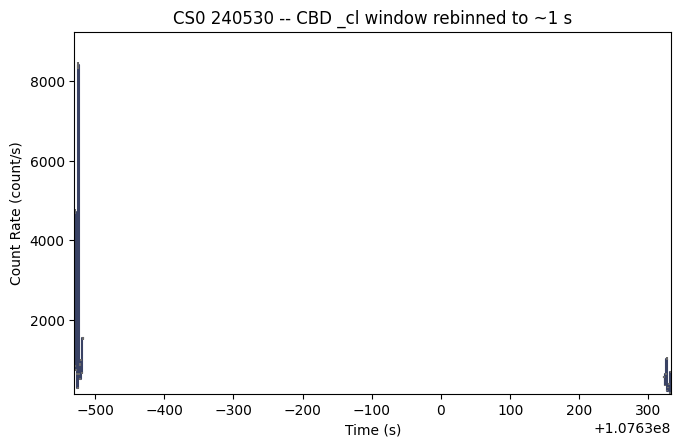

In [8]:
blended_idx = np.flatnonzero(cbd_cl.blended)
lo = cbd_cl.data.tstart[blended_idx[3] + 1]
hi = cbd_cl.data.tstart[blended_idx[4] - 1]
window = cbd_cl.slice_time([(lo, hi)])
print(f'window has {window.data.size[0]} bins, 0 flagged blended: {window.blended is None}')

rebinned = window.rebin_time(combine_by_factor, 4)  # 0.256 s -> ~1.024 s
print(f'{window.data.size[0]} bins -> {rebinned.data.size[0]} bins after rebinning by a factor of 4')
print(f'total counts conserved: {window.data.counts.sum()} -> {rebinned.data.counts.sum()}')

lcplot = Lightcurve(data=rebinned.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl window rebinned to ~1 s')
plt.show()

## Count spectra

Integrating over time instead of energy, with `to_spectrum()`, gives an
`EnergyBins` object -- the 16-channel CBD count spectrum.

/usr/local/lib/python3.11/dist-packages/gdt/core/plot/spectrum.py:154: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  self._ax.set_xlim(data.range)


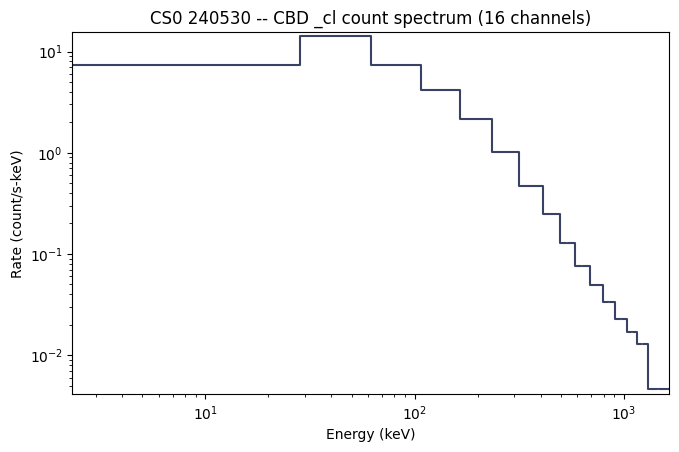

In [9]:
spectrum = cbd_cl.to_spectrum()
specplot = Spectrum(data=spectrum)
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl count spectrum (16 channels)')
plt.show()

## TTE: unbinned events, and a header caveat that is **not** in the official document

TTE gives every photon's arrival time and 1024-channel pulse height.

Its `EVENTS` header `TSTART`/`TSTOP` cannot be trusted -- and this is **not**
a quirk of this one file, and **not** described anywhere in the official
archive caveats document. It affects **every** one of the archive's 28 TTE
files (7 days x 4 detectors), verified by reading all 28:

* all 28 store `TSTART`/`TSTOP` as FITS *strings* rather than numbers, and in
  all 28 `TSTOP - TSTART` disagrees with the file's own `ONTIME`;
* 16 of the 28 (days 240530, 240602, 240813, 240815) additionally have
  `TSTOP < TSTART`, which makes `TELAPSE`/`EXPOSURE` negative and leaves the
  primary header's `DATE-END` *earlier* than its `DATE-OBS`;
* the other 12 (days 240628, 240629, 240814) have `TSTOP > TSTART`, but the
  span still disagrees with `ONTIME`.

What *is* reliable: the `STDGTI` extension's `START`/`STOP` reproduce the
span of the actual event times **exactly** (0.000 s) in all 28 files, and
`ONTIME` agrees with that span to <= 0.7 ms. That is why `BurstCubeTTE.open()`
ignores `TSTART`/`TSTOP` entirely, derives the time range from `STDGTI` and
the events instead, and raises a `UserWarning` so the problem isn't silent.

The official caveats document's caveat #4 is about how few TTE files were
ever downlinked (34 short commissioning/validation windows, mission-wide) and
caveat #5 is about a 2024-08-15 timeline-alignment issue -- neither one
mentions these header keywords. See the README's *TTE TSTART/TSTOP are
unusable in every file* section for the full per-day table; it is not
reproduced here.

In [10]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    tte = BurstCubeTTE.open(tte_path)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')

print(tte)
print(f'{tte.data.size} events, energy range {tte.energy_range} keV')

<BurstCubeTTE: bc240530cs0_tte_uf.evt.gz;
 time range (np.float64(107629263.534), np.float64(107629558.606));
 energy range (16.219999313354492, 1429.68994140625)>
6364 events, energy range (16.219999313354492, 1429.68994140625) keV


## Binning TTE

`to_phaii()` bins the event list in time using any gdt-core unbinned-data
binning function, such as `bin_by_time` for a fixed bin width -- here, the
same 0.256 s as native CBD.

6364 events -> 6364 total binned counts (must match exactly) in 1153 bins


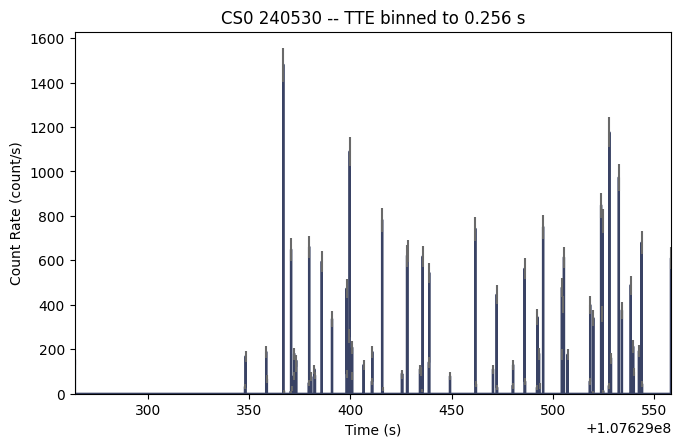

In [11]:
from gdt.core.phaii import Phaii

tte_phaii = tte.to_phaii(bin_by_time, 0.256, phaii_class=Phaii)
print(f'{tte.data.size} events -> {tte_phaii.data.counts.sum():.0f} total binned counts '
     f'(must match exactly) in {tte_phaii.data.size[0]} bins')

lcplot = Lightcurve(data=tte_phaii.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- TTE binned to 0.256 s')
plt.show()

## TTE energy channels: 1024 native, 64 for folding a response

TTE's energy calibration (CALDB `eb1024`) has 1024 channels -- far finer than
CBD's 16. There is deliberately no `Rsp.to_tte()`; instead,
`BurstCubeTTE.to_64_channels()` applies the CALDB `reb64` grouping so TTE can
be folded against the detector's native 64-channel response (see the response
notebook).

In [12]:
tte64 = tte.to_64_channels()
print(f'{tte.num_chans} channels -> {tte64.num_chans} channels; '
     f'{tte.data.size} -> {tte64.data.size} events (unchanged, just regrouped)')

1024 channels -> 64 channels; 6364 -> 6364 events (unchanged, just regrouped)


### TTE arrives in short bursts, not continuously

The light curve just above already shows this: counts arrive in roughly
forty separated spikes across the 295 s span, not spread evenly across it.
Look at the actual inter-event gaps to confirm it:

In [13]:
event_times = np.sort(tte.data.times)
gaps = np.diff(event_times)
nominal_span = tte.time_range[1] - tte.time_range[0]
big_gaps = gaps[gaps > 1.0]

print(f'{tte.data.size} events over a nominal span of {nominal_span:.2f} s')
print(f'inter-event gap (s): median={np.median(gaps):.3f}  '
     f'99th percentile={np.percentile(gaps, 99):.3f}  max={gaps.max():.2f}')
print(f'{big_gaps.size} gaps exceed 1 s, totalling {big_gaps.sum():.2f} s of the '
     f'{nominal_span:.2f} s span -- the great majority of the nominal window is '
     'dead time between short recording bursts, not missing data.')


6364 events over a nominal span of 295.07 s
inter-event gap (s): median=0.000  99th percentile=0.022  max=84.27
40 gaps exceed 1 s, totalling 282.19 s of the 295.07 s span -- the great majority of the nominal window is dead time between short recording bursts, not missing data.


### Why dividing by the nominal span is wrong

A naive rate estimate -- total events divided by the *nominal* 295.07 s
span, as if TTE recorded continuously across it -- does not measure a count
rate. It measures TTE's duty cycle:

In [14]:
naive_rate = tte.data.size / nominal_span
print(f'{tte.data.size} events / {nominal_span:.2f} s nominal span = '
     f'{naive_rate:.1f} ct/s')
print('This is WRONG as a count rate -- most of that span is dead time, not '
     'recording. It is a duty-cycle number, not a physical rate, and comparing '
     'it to CBD (which really does count continuously) makes CBD look ~100x '
     'busier than TTE for no physical reason.')

6364 events / 295.07 s nominal span = 21.6 ct/s
This is WRONG as a count rate -- most of that span is dead time, not recording. It is a duty-cycle number, not a physical rate, and comparing it to CBD (which really does count continuously) makes CBD look ~100x busier than TTE for no physical reason.


### The correct comparison: TTE's actual recording blocks

Group events into contiguous recording blocks -- a gap below some threshold
stays inside a block, a gap above it starts a new one -- then sum TTE's
*actual* active time (the sum of the individual block durations, not the
nominal span), and sum CBD only over the CBD bins that overlap those same
blocks:

In [15]:
def tte_active_blocks(times, gap_threshold):
    """Split sorted event times into contiguous recording blocks, wherever
    the gap to the next event exceeds `gap_threshold`."""
    dt = np.diff(times)
    gap_idx = np.flatnonzero(dt > gap_threshold)
    starts = np.concatenate(([0], gap_idx + 1))
    stops = np.concatenate((gap_idx, [times.size - 1]))
    return list(zip(times[starts], times[stops]))


def cbd_rate_over_blocks(cbd_obj, blocks):
    """Sum a CBD file's counts and exposure over whichever of its bins
    overlap any of the given blocks (each CBD bin counted at most once, even
    if it overlaps more than one block)."""
    tstart, tstop = cbd_obj.data.tstart, cbd_obj.data.tstop
    mask = np.zeros(tstart.size, dtype=bool)
    for block_start, block_stop in blocks:
        mask |= (tstop > block_start) & (tstart < block_stop)
    counts = cbd_obj.data.counts[mask].sum(axis=0)
    exposure = cbd_obj.data.exposure[mask].sum()
    return counts, exposure, mask.sum()


GAP_THRESHOLD = 0.25  # s -- comparable to CBD's own 0.256 s bin width

blocks = tte_active_blocks(event_times, GAP_THRESHOLD)
active_s = sum(stop - start for start, stop in blocks)
tte_rate = tte.data.size / active_s

cbd_counts_16, cbd_exposure, n_cbd_bins = cbd_rate_over_blocks(cbd_cl, blocks)
cbd_rate = cbd_counts_16.sum() / cbd_exposure

print(f'{len(blocks)} recording blocks at a {GAP_THRESHOLD} s gap threshold, '
     f'{active_s:.2f} s of actual TTE recording time (of {nominal_span:.2f} s nominal)')
print(f'TTE rate over its own active time: {tte.data.size} events / {active_s:.2f} s '
     f'= {tte_rate:.1f} ct/s')
print(f'CBD _cl rate over the {n_cbd_bins} bins overlapping those blocks: '
     f'{cbd_counts_16.sum():.0f} counts / {cbd_exposure:.2f} s = {cbd_rate:.1f} ct/s')
print(f'ratio CBD/TTE = {cbd_rate / tte_rate:.2f} -- agreement at the '
     f'{abs(cbd_rate / tte_rate - 1) * 100:.0f}% level, not the ~100x the naive '
     'method above suggested.')


48 recording blocks at a 0.25 s gap threshold, 8.06 s of actual TTE recording time (of 295.07 s nominal)
TTE rate over its own active time: 6364 events / 8.06 s = 789.2 ct/s
CBD _cl rate over the 45 bins overlapping those blocks: 10536 counts / 11.52 s = 914.6 ct/s
ratio CBD/TTE = 1.16 -- agreement at the 16% level, not the ~100x the naive method above suggested.


The result depends on the exact gap threshold used to define a block, which
is itself informative -- sweep it:

In [16]:
print(f'{"gap thr":>8} {"blocks":>7} {"active_s":>9} {"TTE ct/s":>9} {"CBD ct/s":>9} {"CBD/TTE":>8}')
for thr in (0.1, 0.25, 0.5, 1.0, 2.0, 5.0):
    thr_blocks = tte_active_blocks(event_times, thr)
    thr_active_s = sum(stop - start for start, stop in thr_blocks)
    thr_tte_rate = tte.data.size / thr_active_s
    thr_cbd_counts, thr_cbd_exposure, _ = cbd_rate_over_blocks(cbd_cl, thr_blocks)
    thr_cbd_rate = thr_cbd_counts.sum() / thr_cbd_exposure
    print(f'{thr:8.2f} {len(thr_blocks):7d} {thr_active_s:9.2f} {thr_tte_rate:9.1f} '
         f'{thr_cbd_rate:9.1f} {thr_cbd_rate / thr_tte_rate:8.2f}')

 gap thr  blocks  active_s  TTE ct/s  CBD ct/s  CBD/TTE
    0.10      48      8.06     789.2     914.6     1.16
    0.25      48      8.06     789.2     914.6     1.16
    0.50      46      9.05     703.1     914.6     1.30
    1.00      41     12.88     494.0     963.4     1.95
    2.00      30     28.49     223.4    1070.3     4.79
    5.00      19     67.10      94.8    1104.5    11.65


At the tight thresholds (0.1-0.25 s), which best isolate the real recording
bursts without merging in extra dead time, TTE and CBD agree to within
~15-20% -- nowhere near the ~100x the naive method gave above. As the
threshold loosens, the ratio climbs steadily: a looser threshold folds more
of TTE's own dead time into its "active" estimate (pushing TTE's rate down),
while CBD keeps counting throughout regardless (pushing its rate, averaged
over a wider window, up). That the disagreement tracks the threshold this
cleanly is itself a good sign that the ~100x from the naive comparison was a
duty-cycle artifact of the comparison method, not a real difference between
the two data types.

### Energy-channel comparison, using the active blocks

Repeat the two TTE energy groupings from the top of this section -- 64
channels (`to_64_channels()`) and 16 channels via CALDB `reb16` -- restricted
to the same 0.25 s active blocks, and compare the 16-channel grouping
against CBD's own 16-channel data over the same blocks. Because the matched
TTE active time (8.06 s) and the matched CBD bin exposure (11.52 s) are not
equal, the comparison uses each side's own count *rate*, not raw counts.

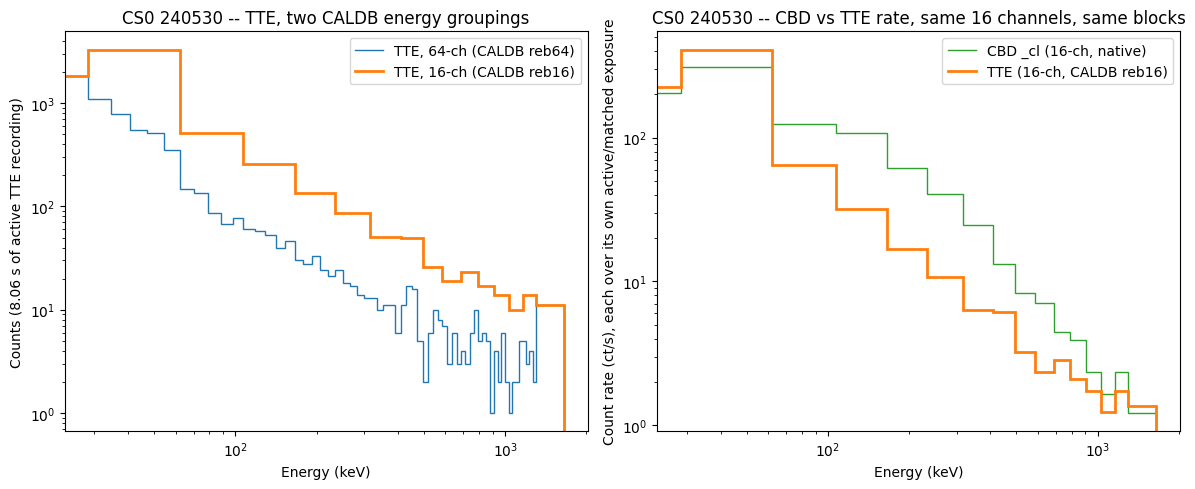

In [17]:
from gdt.missions.burstcube import caldb


def to_n_channels(tte_obj, nchan):
    """Regroup a BurstCubeTTE to `nchan` channels using the CALDB
    `reb{nchan}` scheme -- the same mechanism `to_64_channels()` uses
    internally, generalized to any CALDB rebin scheme (16 or 64)."""
    reb = caldb.rebin(tte_obj.detector, nchan)
    new_edges = np.append(reb.chan_min, reb.chan_max[-1] + 1)

    def _group_by_caldb_edges(counts, count_uncert, exposure, old_edges):
        return counts, count_uncert, exposure, new_edges

    return tte_obj.rebin_energy(_group_by_caldb_edges)


def tte_channel_counts(tte_obj, nchan, blocks):
    times = tte_obj.data.times
    mask = np.zeros(times.size, dtype=bool)
    for block_start, block_stop in blocks:
        mask |= (times >= block_start) & (times <= block_stop)
    return np.bincount(tte_obj.data.channels[mask], minlength=nchan)


tte16 = to_n_channels(tte, 16)

counts_64 = tte_channel_counts(tte64, 64, blocks)
counts_16 = tte_channel_counts(tte16, 16, blocks)
assert counts_16.sum() == tte.data.size  # every event belongs to some block

eb16 = caldb.ebounds(DETECTOR, 16)
edges16 = np.append(eb16.low_edges(), eb16.high_edges()[-1])
edges64 = np.append(tte64.data.ebounds.low_edges(), tte64.data.ebounds.high_edges()[-1])

tte_rate_16 = counts_16 / active_s
cbd_rate_16 = cbd_counts_16 / cbd_exposure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].stairs(counts_64, edges64, label='TTE, 64-ch (CALDB reb64)', color='C0')
axes[0].stairs(counts_16, edges16, label='TTE, 16-ch (CALDB reb16)', color='C1', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Energy (keV)')
axes[0].set_ylabel(f'Counts ({active_s:.2f} s of active TTE recording)')
axes[0].set_title(f'{DETECTOR} {OBS_ID} -- TTE, two CALDB energy groupings')
axes[0].legend()

axes[1].stairs(cbd_rate_16, edges16, label='CBD _cl (16-ch, native)', color='C2')
axes[1].stairs(tte_rate_16, edges16, label='TTE (16-ch, CALDB reb16)', color='C1', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Energy (keV)')
axes[1].set_ylabel('Count rate (ct/s), each over its own active/matched exposure')
axes[1].set_title(f'{DETECTOR} {OBS_ID} -- CBD vs TTE rate, same 16 channels, same blocks')
axes[1].legend()

fig.tight_layout()
plt.show()

In [18]:
print(f'{GAP_THRESHOLD} s active blocks -- CBD exposure {cbd_exposure:.2f} s, '
     f'TTE active time {active_s:.2f} s -- rate per channel, not raw counts:\n')
print(f'{"chan":>4} {"E range (keV)":>18} {"CBD ct/s":>10} {"TTE ct/s":>10} {"CBD/TTE":>8}')
for i in range(16):
    ratio = cbd_rate_16[i] / tte_rate_16[i] if tte_rate_16[i] > 0 else np.nan
    erange = f'{eb16.low_edges()[i]:.1f}-{eb16.high_edges()[i]:.1f}'
    print(f'{i:4d} {erange:>18} {cbd_rate_16[i]:10.2f} {tte_rate_16[i]:10.2f} {ratio:8.2f}')

print(f'\nTotals: CBD = {cbd_rate:.1f} ct/s, TTE = {tte_rate:.1f} ct/s, '
     f'ratio = {cbd_rate / tte_rate:.2f}')

0.25 s active blocks -- CBD exposure 11.52 s, TTE active time 8.06 s -- rate per channel, not raw counts:

chan      E range (keV)   CBD ct/s   TTE ct/s  CBD/TTE
   0           0.0-28.5     203.39     226.69     0.90
   1          28.5-62.2     309.29     410.09     0.75
   2         62.2-106.9     123.44      63.99     1.93
   3        106.9-165.6     107.47      31.87     3.37
   4        165.6-233.9      61.81      16.87     3.66
   5        233.9-316.5      40.28      10.66     3.78
   6        316.5-410.8      24.48       6.32     3.87
   7        410.8-494.5      13.19       6.08     2.17
   8        494.5-585.1       8.33       3.22     2.58
   9        585.1-686.0       7.03       2.36     2.98
  10        686.0-792.3       4.43       2.85     1.55
  11        792.3-907.6       3.91       2.11     1.85
  12       907.6-1030.3       2.34       1.74     1.35
  13      1030.3-1160.7       1.65       1.24     1.33
  14      1160.7-1298.8       2.34       1.74     1.35
  15      129

Once TTE is compared over the time it actually spent recording, the total
rate agrees with CBD to within about 16% -- not the ~100x the naive
comparison at the start of this subsection gave. Per channel there is more
scatter (the table above ranges from CBD/TTE = 0.75 to 3.87), which is
unsurprising given only 8.06 s of active TTE time and a handful of counts in
the higher channels. The residual could come from CBD's coarser 0.256 s bin
edges against TTE's much shorter sub-second blocks, deadtime, or threshold
differences between the two data paths; this dataset does not let us
separate those, so we leave it there.

## Caveat: the mid-mission energy threshold change

Per archive caveat #7, the per-detector low-energy trigger thresholds were
raised roughly mid-mission (from ~21-30 keV to ~100 keV) to suppress a
non-Poissonian noise component. `DETECTOR_HK2`'s `PEAK_THRES`/`BASE_THRES`
columns (60 s cadence, one value per detector) are how that shows up in the
housekeeping data; a single day's file only shows one side of that change,
so comparing an early-mission and late-mission day's HK is what actually
demonstrates it.

In [19]:
hk = BurstCubeHK.open(hk_path)
peak = hk.peak_threshold(DETECTOR)
print(f'{OBS_ID} {DETECTOR} PEAK_THRES (mV), first/last HK2 row: {peak[0]:.2f} / {peak[-1]:.2f}')
print(f'DET_ENABLED (all 4 detectors), first HK1 row: {hk.det_enabled()[0]}')

240530 CS0 PEAK_THRES (mV), first/last HK2 row: 6.00 / 6.00
DET_ENABLED (all 4 detectors), first HK1 row: [0 0 0 0]


## Summary

* CBD is pre-binned (16 channels); TTE is unbinned (1024 channels, folds to
  64 to match the full response binning).
* `_uf` keeps everything; `_cl` removes bad/unphysical intervals.
* At least one real TTE file's header timing keywords are broken; the
  reader works around it and tells you so.
* Detector thresholds changed mid-mission; `DETECTOR_HK2` is where to look.